<a href="https://www.kaggle.com/code/lalit7881/global-tech-ai-startups-dataset-2020-26-eda?scriptVersionId=340079167" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
# Suppress warnings for cleaner output
import warnings
warnings.filterwarnings('ignore')
# Visualization libraries
import matplotlib
matplotlib.use('Agg')  # Ensuring matplotlib backend is set appropriately
import matplotlib.pyplot as plt
%matplotlib inline

import seaborn as sns

# Machine learning libraries
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, roc_curve, auc

# For path handling and dynamic file resolution
from pathlib import Path

# Define data roots and helper method for dynamic file resolution
DATA_ROOTS = [
    Path('/kaggle/input'),
    Path('/kaggle/input'),
    Path('/kaggle/input/datasets'),
]

def resolve_data_file(file_name=None, suffixes=None):
    suffixes = tuple(suffixes or [])
    for root in DATA_ROOTS:
        if not root.exists():
            continue
        matches = [p for p in root.rglob('*') if p.is_file()]
        if file_name:
            exact = [p for p in matches if p.name == file_name]
            if exact:
                return exact[0]
        if suffixes:
            typed = [p for p in matches if p.suffix.lower() in suffixes]
            if typed:
                return typed[0]
    raise FileNotFoundError(f'Could not resolve data file: {file_name or suffixes}')

print('Imports and configuration completed.')
# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

Imports and configuration completed.
/kaggle/input/datasets/saitejabandaruin/automated-pipeline-dataset-output/global_tech_startups_2026.csv


## Loading dataset

In [2]:
# Dynamically resolve the file path for our dataset
file_path = resolve_data_file(file_name='global_tech_startups_2026.csv', suffixes=['.csv'])

# Read in the CSV file. We assume the delimiter is a comma and encoding is ascii as per the description.
df = pd.read_csv(file_path, delimiter=',', encoding='ascii')

In [3]:
# Display the first few rows of the dataframe
print('Data loaded successfully. First 5 rows:')
print(df.head())


Data loaded successfully. First 5 rows:
  Company_ID         Domain  Founding_Year Country           City  \
0   B730AD52     HealthTech           2014  Canada       Montreal   
1   65A5F690    Web3/Crypto           2014   China        Beijing   
2   F106C853  Cybersecurity           2020     USA  San Francisco   
3   2BD798AF        FinTech           2023   India      Delhi NCR   
4   C5CB4451  Generative AI           2020     USA       New York   

  Funding_Stage  Total_Funding_USD_Millions  Valuation_USD_Millions  \
0          Seed                        1.64                   17.81   
1       Pre-IPO                      103.87                  949.16   
2      Series A                       10.08                   43.37   
3      Series B                       32.28                  257.62   
4     Series C+                       13.41                   76.73   

   Revenue_ARR_Millions  Monthly_Burn_Rate_Millions  Runway_Months_2024  \
0                  1.46                    

In [4]:
# Basic information about the dataframe
print('\nDataFrame Info:')
print(df.info())


DataFrame Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25000 entries, 0 to 24999
Data columns (total 17 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Company_ID                  25000 non-null  object 
 1   Domain                      25000 non-null  object 
 2   Founding_Year               25000 non-null  int64  
 3   Country                     25000 non-null  object 
 4   City                        25000 non-null  object 
 5   Funding_Stage               25000 non-null  object 
 6   Total_Funding_USD_Millions  25000 non-null  float64
 7   Valuation_USD_Millions      25000 non-null  float64
 8   Revenue_ARR_Millions        25000 non-null  float64
 9   Monthly_Burn_Rate_Millions  25000 non-null  float64
 10  Runway_Months_2024          25000 non-null  float64
 11  Peak_Headcount_2023         25000 non-null  int64  
 12  Layoffs_2024_2025           25000 non-null  int64  
 13  Current_Headco

In [5]:
print('\nSummary statistics:')
print(df.describe())


Summary statistics:
       Founding_Year  Total_Funding_USD_Millions  Valuation_USD_Millions  \
count   25000.000000                25000.000000            25000.000000   
mean     2018.917400                   59.631098              464.100121   
std         2.811963                  208.725699             1777.909318   
min      2012.000000                    0.000000                1.030000   
25%      2017.000000                    2.050000               28.997500   
50%      2019.000000                    8.465000               71.775000   
75%      2021.000000                   36.100000              267.795000   
max      2025.000000                 7867.390000            91692.420000   

       Revenue_ARR_Millions  Monthly_Burn_Rate_Millions  Runway_Months_2024  \
count          25000.000000                25000.000000        25000.000000   
mean              33.300890                    3.168847           12.189032   
std              139.243809                   10.877553  

In [6]:
df.duplicated().sum()

np.int64(0)

In [7]:
df.columns

Index(['Company_ID', 'Domain', 'Founding_Year', 'Country', 'City',
       'Funding_Stage', 'Total_Funding_USD_Millions', 'Valuation_USD_Millions',
       'Revenue_ARR_Millions', 'Monthly_Burn_Rate_Millions',
       'Runway_Months_2024', 'Peak_Headcount_2023', 'Layoffs_2024_2025',
       'Current_Headcount_2026', 'Investor_Tier', 'AI_Adoption_Level',
       'Acquisition_Status'],
      dtype='object')

In [8]:
df.nunique()

Company_ID                    24999
Domain                           10
Founding_Year                    14
Country                          10
City                             29
Funding_Stage                     6
Total_Funding_USD_Millions     8473
Valuation_USD_Millions        16439
Revenue_ARR_Millions           6457
Monthly_Burn_Rate_Millions     2142
Runway_Months_2024              596
Peak_Headcount_2023            1748
Layoffs_2024_2025               641
Current_Headcount_2026         1616
Investor_Tier                     5
AI_Adoption_Level                 3
Acquisition_Status                5
dtype: int64

## EDA

In [9]:
for col in df.columns:
    if df[col].dtype in [np.float64, np.int64]:
        df[col].fillna(df[col].mean(), inplace=True)
    else:
        df[col].fillna('Unknown', inplace=True)

# Convert data types if necessary (as per the dataset description, data is already of the correct types).
df['Founding_Year'] = df['Founding_Year'].astype(int)
df['Peak_Headcount_2023'] = df['Peak_Headcount_2023'].astype(int)
df['Layoffs_2024_2025'] = df['Layoffs_2024_2025'].astype(int)
df['Current_Headcount_2026'] = df['Current_Headcount_2026'].astype(int)

print('\nData cleaning and preprocessing completed.')


Data cleaning and preprocessing completed.


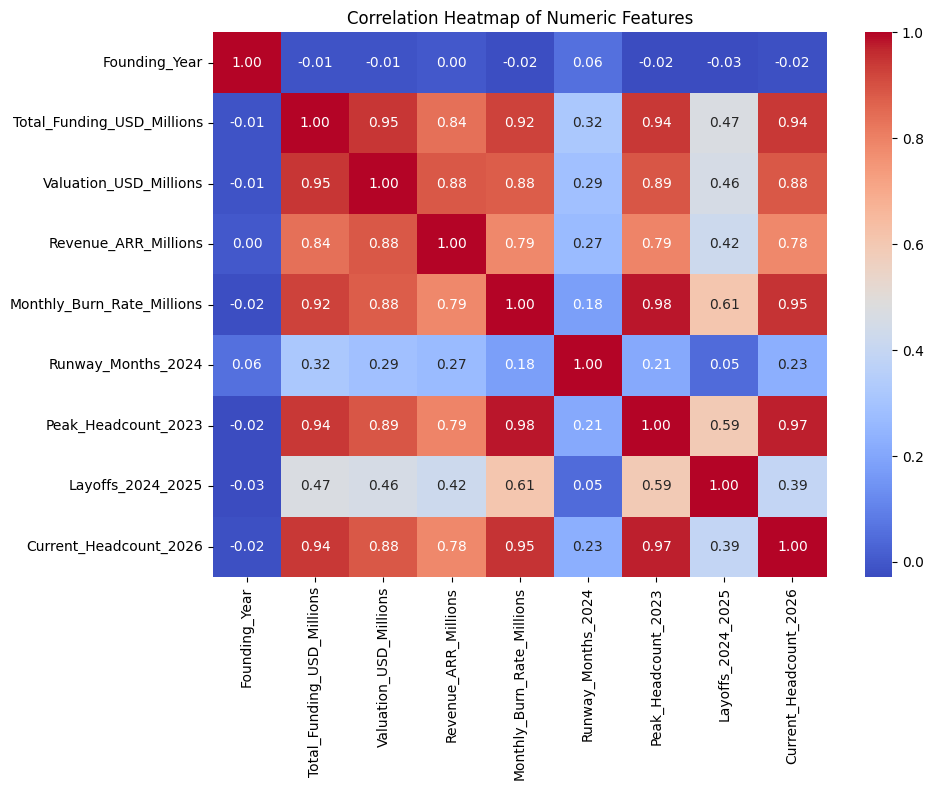

In [10]:
# Identify numeric columns
numeric_df = df.select_dtypes(include=[np.number])

# If four or more numeric columns are found, create a correlation heatmap
if numeric_df.shape[1] >= 4:
    plt.figure(figsize=(10,8))
    corr_matrix = numeric_df.corr()
    sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm')
    plt.title('Correlation Heatmap of Numeric Features')
    plt.tight_layout()
    plt.savefig('correlation_heatmap.png')
    plt.show()

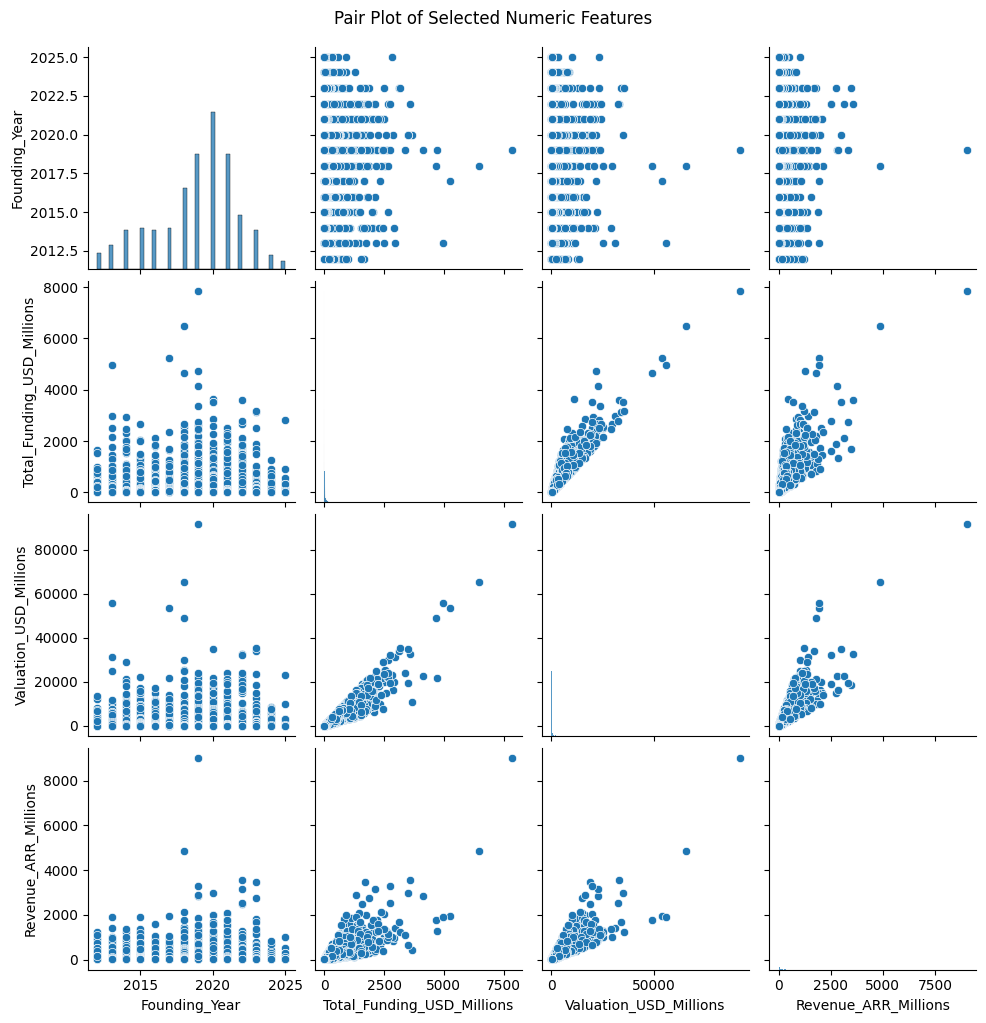

In [11]:
# Pair Plot of selected numeric columns to inspect pairwise distributions
selected_cols = numeric_df.columns[:4]  # selecting first 4 numeric columns for clarity in visualization
sns.pairplot(numeric_df[selected_cols])
plt.suptitle('Pair Plot of Selected Numeric Features', y=1.02)
plt.savefig('pairplot.png')
plt.show()

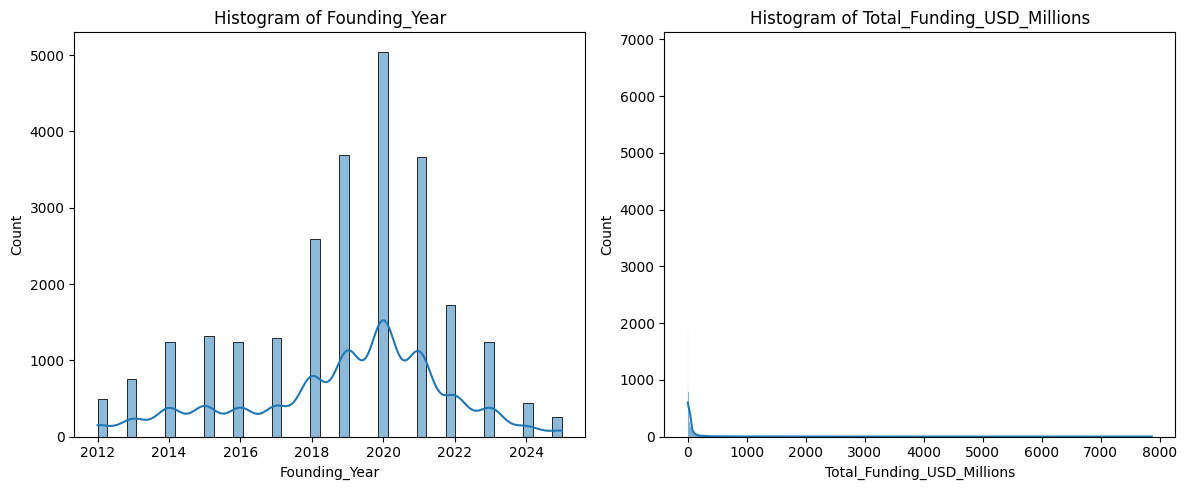

In [12]:
# Histogram for a couple of numeric features
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
sns.histplot(numeric_df[selected_cols[0]], kde=True)
plt.title(f'Histogram of {selected_cols[0]}')

plt.subplot(1,2,2)
sns.histplot(numeric_df[selected_cols[1]], kde=True)
plt.title(f'Histogram of {selected_cols[1]}')

plt.tight_layout()
plt.savefig('histograms.png')
plt.show()

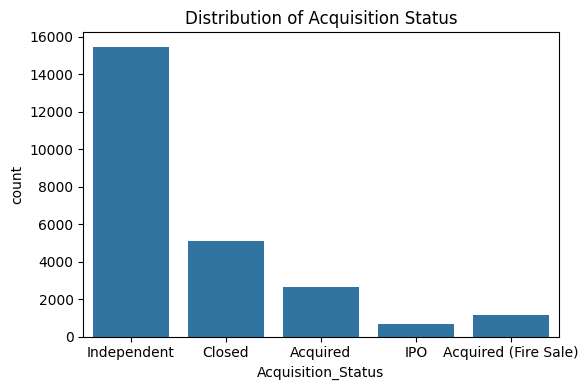

In [13]:
# Count plot for a categorical feature. For instance, Acquisition_Status
plt.figure(figsize=(6,4))
sns.countplot(data=df, x='Acquisition_Status')
plt.title('Distribution of Acquisition Status')
plt.tight_layout()
plt.savefig('acquisition_status_count.png')
plt.show()

## Feature engineering

In [14]:
# Copy the dataframe for modeling
model_df = df.copy()

# Define the target variable. We assume 'Acquisition_Status' is our classification target.
target = 'Acquisition_Status'

# Keep features excluding identifiers that may not be useful for prediction
drop_columns = ['Company_ID', 'Domain']
features_df = model_df.drop(columns=drop_columns + [target])

# Convert categorical features into dummy variables
features_df = pd.get_dummies(features_df, drop_first=True)

# Encode the target as a binary label if there are exactly two classes; otherwise, use label encoding
if model_df[target].nunique() == 2:
    # Map the two classes to 0 and 1
    model_df[target] = model_df[target].apply(lambda x: 1 if x.lower() in ['acquired', 'yes', 'true'] else 0)
    y = model_df[target]
else:
    from sklearn.preprocessing import LabelEncoder
    le = LabelEncoder()
    y = le.fit_transform(model_df[target])

X = features_df

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Instantiate and train the RandomForestClassifier
clf = RandomForestClassifier(n_estimators=100, random_state=42)
clf.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

Prediction Accuracy: 0.6692


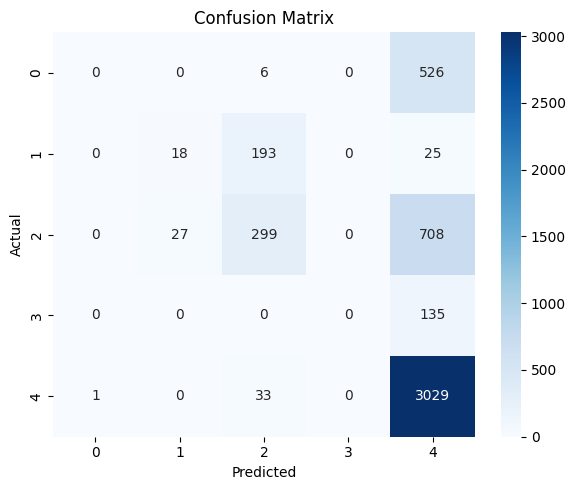

In [15]:
# Make predictions on the test set and compute accuracy
y_pred = clf.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print('Prediction Accuracy:', accuracy)

# Plotting the confusion matrix
conf_mat = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,5))
sns.heatmap(conf_mat, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.tight_layout()
plt.savefig('confusion_matrix.png')
plt.show()

ROC curve not generated because the target variable is not binary.


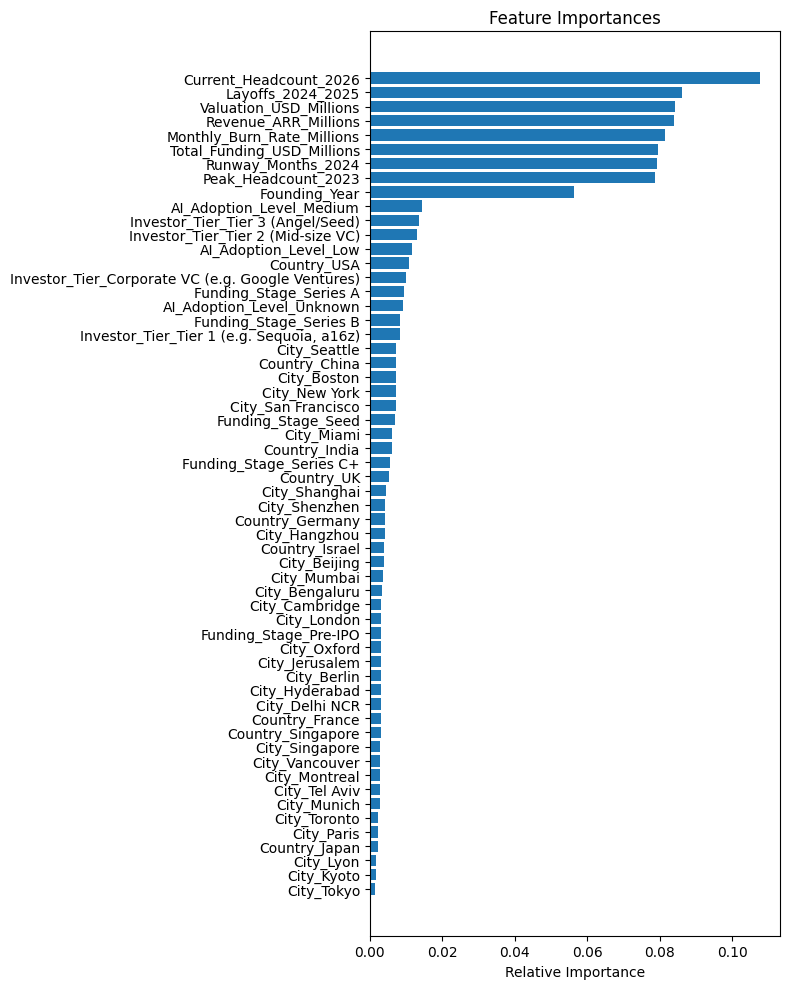

In [16]:
# Plot the ROC Curve if binary classification
if len(np.unique(y_test)) == 2:
    y_pred_proba = clf.predict_proba(X_test)[:,1]
    fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)
    roc_auc = auc(fpr, tpr)

    plt.figure(figsize=(6,5))
    plt.plot(fpr, tpr, label=f'ROC Curve (area = {roc_auc:.2f})')
    plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('ROC Curve')
    plt.legend(loc='lower right')
    plt.tight_layout()
    plt.savefig('roc_curve.png')
    plt.show()
else:
    print('ROC curve not generated because the target variable is not binary.')

# (Optional) Plotting feature importances
importances = clf.feature_importances_
feat_names = X.columns

indices = np.argsort(importances)
plt.figure(figsize=(8,10))
plt.barh(range(len(indices)), importances[indices], align='center')
plt.yticks(range(len(indices)), [feat_names[i] for i in indices])
plt.xlabel('Relative Importance')
plt.title('Feature Importances')
plt.tight_layout()
plt.savefig('feature_importances.png')
plt.show()

## Thank you..pls upvote!!!!!!!!